In [1]:
from mp_api.client import MPRester
import logging
import os
from dotenv import load_dotenv
logger = logging.getLogger(__name__)


load_dotenv()
API_KEY = os.getenv("MP_API_KEY")

    

/home/robot/Desktop/projects/materials-project-mcp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(elements=["Si", "O"], band_gap=(0.5, 1.0))

Retrieving SummaryDoc documents: 100%|██████████| 443/443 [00:00<00:00, 2587850.52it/s]


In [3]:
print(docs)

[MPDataDoc<SummaryDoc>(
builder_meta=EmmetMeta(emmet_version='0.84.7rc1', pymatgen_version='2025.3.10', run_id='13d67e62-d65a-4ffc-8b7f-d2d2e0041e70', batch_id='jmunro_static_calculations', database_version='2025.04.10', build_date=datetime.datetime(2025, 4, 3, 20, 12, 29, 275000), license='BY-C'),
nsites=48,
elements=[Element O, Element Si],
nelements=2,
composition=Composition('Si16 O32'),
composition_reduced=Composition('Si1 O2'),
formula_pretty='SiO2',
formula_anonymous='AB2',
chemsys='O-Si',
volume=975.3631352517338,
density=1.636679902657333,
density_atomic=20.320065317744454,
symmetry=SymmetryData(crystal_system=<CrystalSystem.mono: 'Monoclinic'>, symbol='C2/m', number=12, point_group='2/m', symprec=0.1, angle_tolerance=5.0, version='2.6.0'),
property_name='summary',
material_id=MPID(mp-34150),
deprecated=False,
deprecation_reasons=None,
last_updated=datetime.datetime(2025, 4, 9, 17, 10, 44, 176000),
origins=[PropertyOrigin(name='structure', task_id=MPID(mp-1325447), last_update

In [4]:
from mp_api.client import MPRester
from emmet.core.electronic_structure import BSPathType

with MPRester(API_KEY) as mpr:
    # -- line-mode, Setyawan-Curtarolo (default):
    bs_sc = mpr.get_bandstructure_by_material_id("mp-149")
    
    # -- line-mode, Hinuma et al.:
    bs_hin = mpr.get_bandstructure_by_material_id("mp-149", path_type=BSPathType.hinuma)

    # -- line-mode, Latimer-Munro:
    bs_hin = mpr.get_bandstructure_by_material_id("mp-149", path_type=BSPathType.latimer_munro)
    
    # -- uniform:
    bs_uniform = mpr.get_bandstructure_by_material_id("mp-149", line_mode=False)                            

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 8774.69it/s]


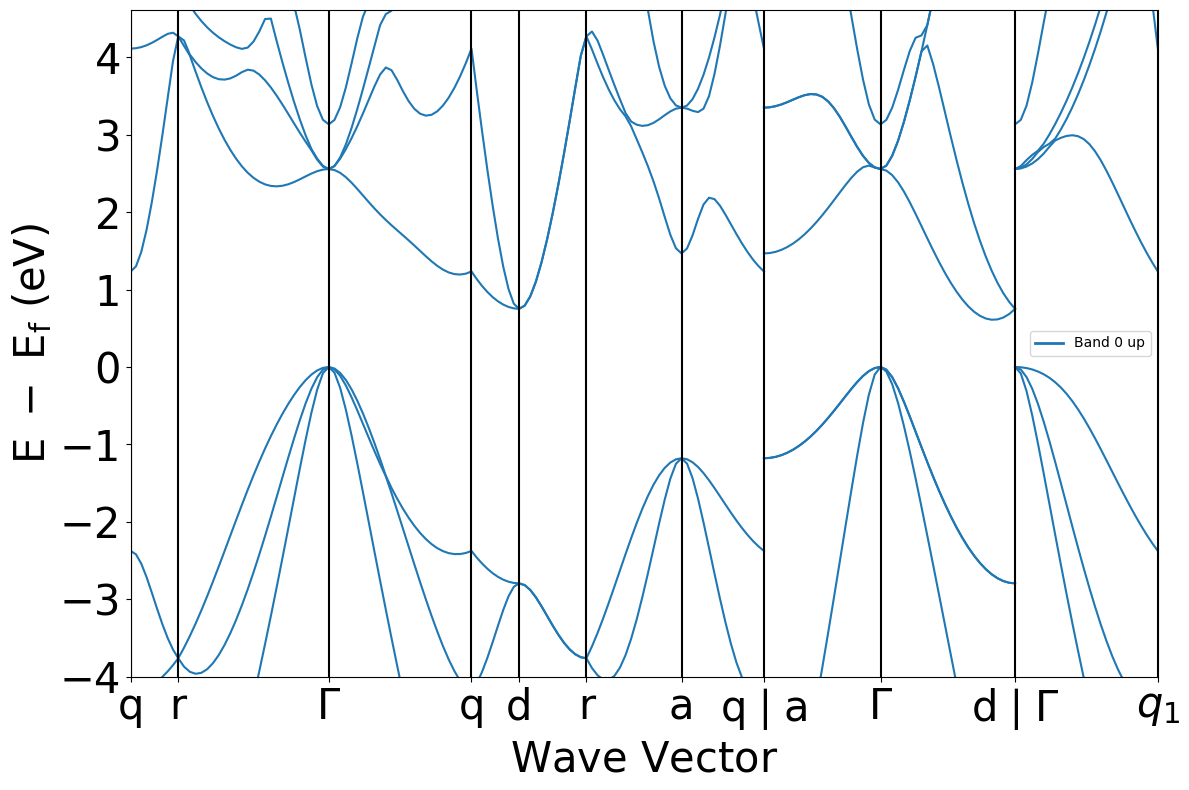

In [5]:
from pymatgen.electronic_structure.plotter import BSPlotter
import matplotlib.pyplot as plt

#bs_plotter = BSPlotter(bs_sc)
#bs_plotter.get_plot()
#plt.show()


bs_hin_plotter = BSPlotter(bs_hin)
bs_hin_plotter.get_plot()
plt.show()





Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 4013.69it/s]


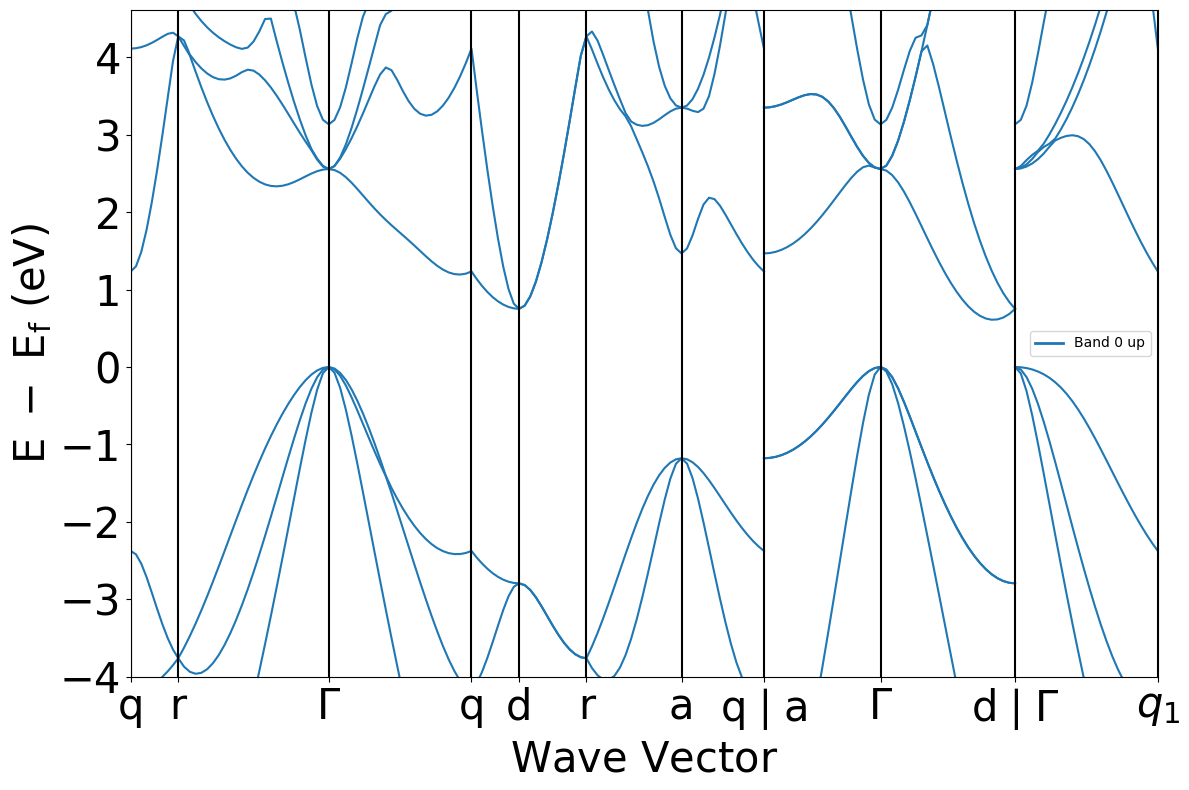

In [6]:
from mp_api.client import MPRester
from emmet.core.electronic_structure import BSPathType
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine

import matplotlib.pyplot as plt
import io
import base64
from IPython.display import Image, display


material_id = "mp-149"
path_type = "latimer_munro"  # or setyawan_curtarolo, hinuma, latimer_munro

with MPRester(API_KEY) as mpr:
    bs = mpr.get_bandstructure_by_material_id(
        material_id,
        path_type=BSPathType(path_type)
    )

if not isinstance(bs, BandStructureSymmLine):
    print(f"Band structure for path_type `{path_type}` is not plottable.")
else:
    plotter = BSPlotter(bs)
    ax = plotter.get_plot()
    fig = ax.get_figure()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)

    display(Image(data=buf.getvalue()))


In [7]:
dos = mpr.get_dos_by_material_id("mp-149")
print(dos)

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 14266.34it/s]


Complete DOS for Full Formula (Si2)
Reduced Formula: Si
abc   :   3.866975   3.866975   3.866975
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Si    0.75  0.75  0.75
  1  Si    0     0     0


Retrieving PhononBSDOSDoc documents: 100%|██████████| 1/1 [00:00<00:00, 5833.52it/s]


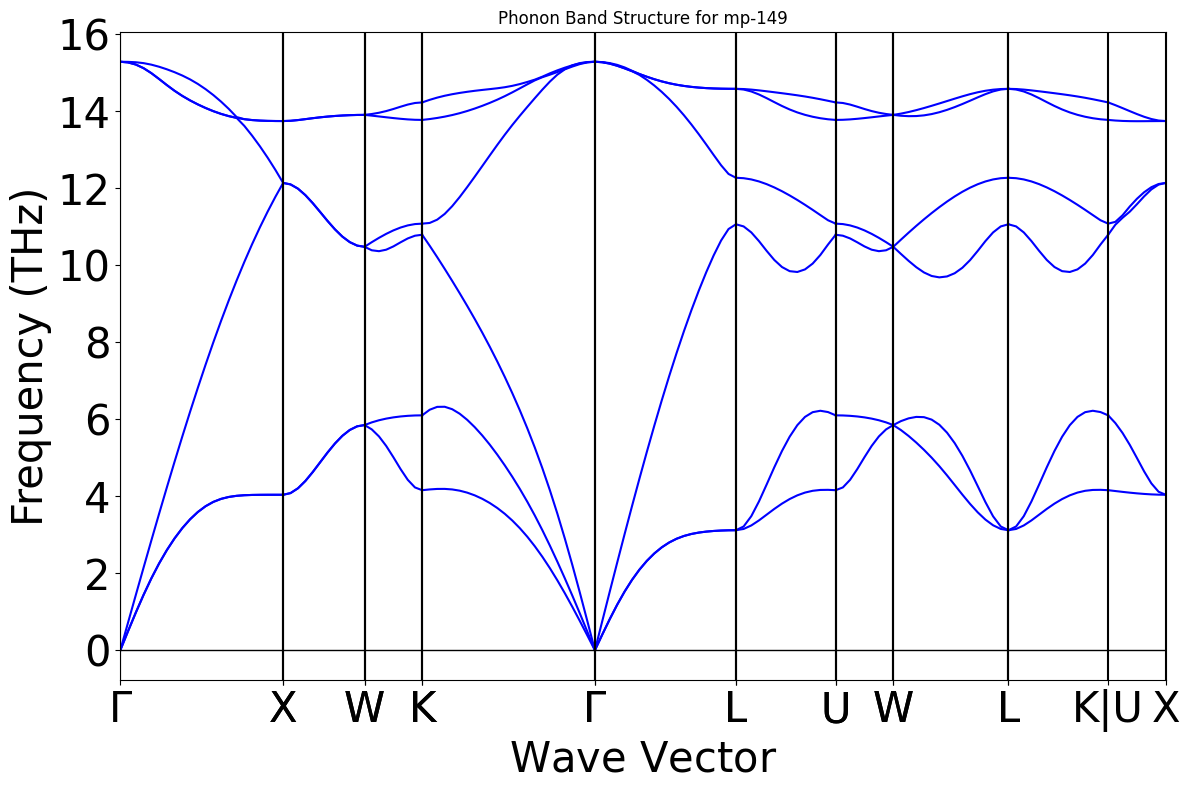

In [8]:
from pymatgen.phonon.bandstructure import PhononBandStructureSymmLine
from pymatgen.phonon.plotter import PhononBSPlotter
import matplotlib.pyplot as plt

def get_phonon_bandstructure(material_id: str):

    with MPRester(API_KEY) as mpr:
        bs = mpr.get_phonon_bandstructure_by_material_id(material_id)
    
    if not isinstance(bs, PhononBandStructureSymmLine):
        raise ValueError("Cannot plot phonon band structure. Only line-mode paths are plottable.")
    
    plotter = PhononBSPlotter(bs)
    fig = plotter.get_plot()
    
    plt.title(f"Phonon Band Structure for {material_id}")
    plt.ylabel("Frequency (THz)")
    plt.tight_layout()
    
    return fig  

if __name__ == "__main__":
    fig = get_phonon_bandstructure("mp-149")  
    plt.show()  

In [9]:
type(bs)


pymatgen.electronic_structure.bandstructure.BandStructureSymmLine

In [10]:
from pydantic import Field


def get_atom_reference_data(
        funcs: tuple[str, ...] = Field(
            default=("PBE",),
            description="list of functionals to retrieve data for "
        )
) -> str:
    """
    Retrieve reference energies of isolated neutral atoms. this energies can be used to calculate formations energies of compounds,
    Write the meaning of these funcs eg thier full names
    Args:
        funcs ([str] or None ) : list of functionals to retrieve data for.
    Returns:
        str : Markdown containing isolated atom energies 
    """
    logger.info("Getting Atom Reference Data")
    with MPRester(API_KEY) as mpr:
        atom_data = mpr.get_atom_reference_data()

    if not atom_data:
        return f"No atom data retrieved for functionals {funcs}"

    atom_references = "| Element | Reference Energy (eV/atom) |\n"

    for element, energy in atom_data.items():
        atom_references += f"| **{element}** | {energy} | \n"

    return atom_references


atom_reference_energies = get_atom_reference_data()
print(atom_reference_energies)

| Element | Reference Energy (eV/atom) |
| **PBE** | {'Ac': -0.386628, 'Ag': -0.338796, 'Al': -0.31215, 'Ar': -0.0502028, 'As': -1.68339, 'Au': -0.287235, 'B': -0.444696, 'Ba': -0.0343695, 'Be': -0.0181095, 'Bi': -1.32598, 'Br': -0.265108, 'C': -1.38655, 'Ca': -0.0927445, 'Cd': -0.167163, 'Ce': -1.38761, 'Cl': -0.371445, 'Co': -2.14965, 'Cr': -5.60185, 'Cs': -0.136948, 'Cu': -0.60265, 'Dy': -0.388635, 'Er': -0.385653, 'Eu': -8.36623, 'F': -0.767378, 'Fe': -3.59548, 'Ga': -0.404345, 'Gd': -10.4088, 'Ge': -0.89163, 'H': -1.11764, 'He': -0.00052786, 'Hf': -3.52698, 'Hg': -0.123457, 'Ho': -0.383445, 'I': -0.170276, 'In': -0.408676, 'Ir': -1.1789, 'K': -0.22773, 'Kr': -0.0331108, 'La': -0.845547, 'Li': -0.297434, 'Lu': -0.380803, 'Mg': -0.0958253, 'Mn': -5.3235, 'Mo': -4.60107, 'N': -3.12556, 'Na': -0.228497, 'Nb': -3.15127, 'Nd': -0.518551, 'Ne': -0.012123, 'Ni': -1.05365, 'Np': -7.70168, 'O': -1.90671, 'Os': -2.89793, 'P': -1.88791, 'Pa': -2.55302, 'Pb': -0.767435, 'Pd': -1.47758, 'Pm': -

In [11]:
from typing import List 


def get_cohesive_energy(
        material_ids: List[str] = Field(
            ...,
            description="List of Material IDs to compute cohesive energies"
        ),
        normalization: str = Field(
            default="atom",
            description="The normalization to use, whether to normalize cohesive energy by number of atoms (deflaut) or by number of formula units  "
        )
):
    """
    Obtain the cohesive energy of the structure(s) corresponding to single or multiple material IDs

    Args:
        material_ids: List to material IDs to compute their cohesive energy
        normalization: Whether to normalize cohesive energy using number of atoms or number of formula

    Returns:
        str: The Markdown of  cohesive energies (in eV/atom or eV/formula unit) for
            each material, indexed by Material IDs .

    """
    logger.info("Getting cohesive energy for material IDs")

    with MPRester(API_KEY) as mpr:
        cohesive_energies = mpr.get_cohesive_energy(material_ids=material_ids, normalization=normalization)

    if not cohesive_energies:
        logger.info(f"No cohesive energy was retrived for {material_ids}")
        return f"No cohesive energies found for these Material IDs: {material_ids}"


    energies = f"## Cohesive Energies \n"
    for identifier, energy in cohesive_energies.items():
        unit = "eV/atom" if normalization == "atom" else "eV/formula unit"
        energies += f"-- **{identifier}** : {energy} {unit}\n"

    return energies


cohesive_energy = get_cohesive_energy(["mp-456"])
cohesive_energy

The 'inc_structure' argument is deprecated as structure data is now always included in all returned entry objects.
Retrieving ThermoDoc documents: 0it [00:00, ?it/s]


'## Cohesive Energies \n-- **mp-456** : None eV/formula unit\n'

In [12]:

with MPRester(api_key=API_KEY) as mpr:
    magnetism_doc = mpr.magnetism.search(material_ids=["mp-20459"])

magnetism_doc



Accessing magnetism data through MPRester.magnetism is deprecated. Please use MPRester.materials.magnetism instead.
Retrieving MagnetismDoc documents: 100%|██████████| 1/1 [00:00<00:00, 5065.58it/s]


[MPDataDoc<MagnetismDoc>(
 builder_meta=EmmetMeta(emmet_version='0.84.3rc4', pymatgen_version='2024.11.13', run_id='5c8ad8eb-1c5e-4547-a1f2-c91ac96ff9a9', batch_id=None, database_version='2025.04.10', build_date=datetime.datetime(2024, 11, 22, 23, 50, 50, 943000), license=None),
 nsites=5,
 elements=[Element O, Element Pb, Element Ti],
 nelements=3,
 composition=Composition('Ti1 Pb1 O3'),
 composition_reduced=Composition('Ti1 Pb1 O3'),
 formula_pretty='TiPbO3',
 formula_anonymous='ABC3',
 chemsys='O-Pb-Ti',
 volume=64.50656431866489,
 density=7.801556471692712,
 density_atomic=12.901312863732977,
 symmetry=SymmetryData(crystal_system=<CrystalSystem.tet: 'Tetragonal'>, symbol='P4mm', number=99, point_group='4mm', symprec=0.1, angle_tolerance=5.0, version='2.5.0'),
 property_name='magnetism',
 material_id=MPID(mp-20459),
 deprecated=False,
 deprecation_reasons=None,
 last_updated=datetime.datetime(2023, 10, 7, 9, 37, 19, 182000),
 origins=[PropertyOrigin(name='magnetism', task_id=MPID(mp

In [13]:
data_md = f""" Magnetic data **"""
for i, model in enumerate(magnetism_doc):
    data_md  += f"idx: {i}"
    data = model.model_dump()
    for key, value in data.items(): 
        data_md += f"|** {key}         |      {value} |\n\n"

data_md


" Magnetic data **idx: 0|** builder_meta         |      {'emmet_version': '0.84.3rc4', 'pymatgen_version': '2024.11.13', 'run_id': '5c8ad8eb-1c5e-4547-a1f2-c91ac96ff9a9', 'batch_id': None, 'database_version': '2025.04.10', 'build_date': datetime.datetime(2024, 11, 22, 23, 50, 50, 943000), 'license': None} |\n\n|** nsites         |      5 |\n\n|** elements         |      [Element O, Element Pb, Element Ti] |\n\n|** nelements         |      3 |\n\n|** composition         |      Ti1 Pb1 O3 |\n\n|** composition_reduced         |      Ti1 Pb1 O3 |\n\n|** formula_pretty         |      TiPbO3 |\n\n|** formula_anonymous         |      ABC3 |\n\n|** chemsys         |      O-Pb-Ti |\n\n|** volume         |      64.50656431866489 |\n\n|** density         |      7.801556471692712 |\n\n|** density_atomic         |      12.901312863732977 |\n\n|** symmetry         |      {'crystal_system': <CrystalSystem.tet: 'Tetragonal'>, 'symbol': 'P4mm', 'number': 99, 'point_group': '4mm', 'symprec': 0.1, 'angle

In [14]:
from mp_api.client import MPRester

with MPRester(api_key=API_KEY) as mpr:
    dielectric_doc = mpr.materials.dielectric.search(material_ids=["mp-20459"])

dielectric_doc

Retrieving DielectricDoc documents: 100%|██████████| 1/1 [00:00<00:00, 3326.17it/s]


[MPDataDoc<DielectricDoc>(
 builder_meta=EmmetMeta(emmet_version='0.84.6rc5', pymatgen_version='2024.11.13', run_id='7d591b38-0601-4532-9557-832970890006', batch_id=None, database_version='2025.04.10', build_date=datetime.datetime(2025, 3, 13, 21, 22, 40, 104000), license=None),
 nsites=5,
 elements=[Element O, Element Pb, Element Ti],
 nelements=3,
 composition=Composition('Ti1 Pb1 O3'),
 composition_reduced=Composition('Ti1 Pb1 O3'),
 formula_pretty='TiPbO3',
 formula_anonymous='ABC3',
 chemsys='O-Pb-Ti',
 volume=68.74893007547018,
 density=7.320137265810557,
 density_atomic=13.749786015094037,
 symmetry=SymmetryData(crystal_system=<CrystalSystem.tet: 'Tetragonal'>, symbol='P4mm', number=99, point_group='4mm', symprec=0.1, angle_tolerance=5.0, version='2.6.0'),
 property_name='dielectric',
 material_id=MPID(mp-20459),
 deprecated=False,
 deprecation_reasons=None,
 last_updated=datetime.datetime(2023, 10, 7, 9, 37, 19, 182000),
 origins=[PropertyOrigin(name='dielectric', task_id=MPID(

In [15]:
type(dielectric_doc[0])

mp_api.client.core.client.MPDataDoc

In [16]:
from mp_api.client import MPRester

# Replace "YOUR_API_KEY" with your actual Materials Project API key
with MPRester(API_KEY) as mpr:
    cohesive_energy = mpr.get_cohesive_energy(
        material_ids=["mp-123", "mp-456"], normalization="atom"
    )
    # cohesive_energy will be a dictionary like {'mp-123': value, 'mp-456': value}
    print(cohesive_energy.get("mp-123"))
    print(cohesive_energy.get("mp-456"))

Retrieving ThermoDoc documents: 100%|██████████| 3/3 [00:00<00:00, 19941.22it/s]
Using UFloat objects with std_dev==0 may give unexpected results.


-4.029208982500002
None


In [17]:
# test charge density retrieval
with MPRester(API_KEY) as mpr:
        charge_density = mpr.get_charge_density_from_material_id(material_id=material_id)

density_data = f"""
            ## Material ID: {material_id}
        
            ### Structure Summary:
            {charge_density.structure}
        
            ### Charge Density (Total):
            {charge_density.data["total"]}
            
            ### Is charge Density Polarized : 
            {charge_density.is_spin_polarized}
            
        """
print(density_data)

Retrieving TaskDoc documents: 100%|██████████| 6/6 [00:00<00:00, 78889.73it/s]



            ## Material ID: mp-149

            ### Structure Summary:
            Full Formula (Si2)
Reduced Formula: Si
abc   :   3.866975   3.866975   3.866975
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Si    0.75  0.75  0.75
  1  Si    0     0     0

            ### Charge Density (Total):
            [[[-7.67076006 -7.1419922  -5.61016114 ... -3.23090062 -5.61016363
   -7.14199403]
  [-7.1419922  -6.156923   -4.28509713 ... -4.28509663 -6.15692336
   -7.14199245]
  [-5.61016114 -4.28509713 -2.2197689  ... -4.2850951  -5.61016021
   -6.06671462]
  ...
  [-3.23090062 -4.28509663 -4.2850951  ...  4.63176918  1.47426635
   -1.23949527]
  [-5.61016363 -6.15692336 -5.61016021 ...  1.47426635 -1.58378568
   -4.0294018 ]
  [-7.14199403 -7.14199245 -6.06671462 ... -1.23949527 -4.0294018
   -6.06671863]]

 [[-7.1419922  -6.156923   -4.28509713 ... -4.28509663 -6.15692336
   -7.1419

In [18]:
with MPRester(API_KEY) as mpr: 
        # first retrieve the relevant structure 
        structure = mpr.get_structure_by_material_id(material_id)

from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

sga = SpacegroupAnalyzer(structure=structure)
conventional_structure  = sga.get_conventional_standard_structure()
calculator = XRDCalculator(wavelength="CuKa")
pattern = calculator.get_pattern(conventional_structure)
pattern

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 14122.24it/s]


DiffractionPattern
$2\Theta$: [28.39765948 47.22550108 56.0283469  69.0085065  76.23752709 87.85984819]
Intensity: [100.          66.70340477  39.62321003  10.72114428  16.3477103
  23.48533665]

In [19]:
type(pattern)

pymatgen.analysis.diffraction.core.DiffractionPattern

In [20]:
str(pattern)

'DiffractionPattern\n$2\\Theta$: [28.39765948 47.22550108 56.0283469  69.0085065  76.23752709 87.85984819]\nIntensity: [100.          66.70340477  39.62321003  10.72114428  16.3477103\n  23.48533665]'

In [21]:
with MPRester(API_KEY) as mpr: 
     elasticity_doc = mpr.materials.elasticity.search(material_ids=["mp-149", "mp-1029739"])

elasticity_doc

Retrieving ElasticityDoc documents: 100%|██████████| 2/2 [00:00<00:00, 22075.28it/s]


[MPDataDoc<ElasticityDoc>(
 builder_meta=EmmetMeta(emmet_version='0.84.6rc5', pymatgen_version='2024.11.13', run_id='594815f4-e1b1-4ff4-9598-f5e9f2d2cc26', batch_id=None, database_version='2025.04.10', build_date=datetime.datetime(2025, 3, 20, 19, 32, 4, 797000), license=None),
 nsites=22,
 elements=[Element Fe, Element Li, Element N],
 nelements=3,
 composition=Composition('Li12 Fe2 N8'),
 composition_reduced=Composition('Li6 Fe1 N4'),
 formula_pretty='Li6FeN4',
 formula_anonymous='AB4C6',
 chemsys='Fe-Li-N',
 volume=205.0509998769669,
 density=2.486428301521116,
 density_atomic=9.320499994407585,
 symmetry=SymmetryData(crystal_system=<CrystalSystem.tet: 'Tetragonal'>, symbol='P4_2/nmc', number=137, point_group='4/mmm', symprec=0.1, angle_tolerance=5.0, version='2.6.0'),
 property_name='elasticity',
 material_id=MPID(mp-1029739),
 deprecated=False,
 deprecation_reasons=None,
 last_updated=datetime.datetime(2025, 3, 20, 19, 32, 4, 797000),
 origins=[],
 warnings=[],
 structure=Structur

In [22]:
print(elasticity_doc)

[MPDataDoc<ElasticityDoc>(
builder_meta=EmmetMeta(emmet_version='0.84.6rc5', pymatgen_version='2024.11.13', run_id='594815f4-e1b1-4ff4-9598-f5e9f2d2cc26', batch_id=None, database_version='2025.04.10', build_date=datetime.datetime(2025, 3, 20, 19, 32, 4, 797000), license=None),
nsites=22,
elements=[Element Fe, Element Li, Element N],
nelements=3,
composition=Composition('Li12 Fe2 N8'),
composition_reduced=Composition('Li6 Fe1 N4'),
formula_pretty='Li6FeN4',
formula_anonymous='AB4C6',
chemsys='Fe-Li-N',
volume=205.0509998769669,
density=2.486428301521116,
density_atomic=9.320499994407585,
symmetry=SymmetryData(crystal_system=<CrystalSystem.tet: 'Tetragonal'>, symbol='P4_2/nmc', number=137, point_group='4/mmm', symprec=0.1, angle_tolerance=5.0, version='2.6.0'),
property_name='elasticity',
material_id=MPID(mp-1029739),
deprecated=False,
deprecation_reasons=None,
last_updated=datetime.datetime(2025, 3, 20, 19, 32, 4, 797000),
origins=[],
warnings=[],
structure=Structure Summary
Lattice
   

In [23]:
data_md = f"|##     Elastic Constants   |\n\n"
for idx, model in enumerate(elasticity_doc):
    data_md += f"idx : {idx}"
    data = model.model_dump()
    for key, value in data.items():
        data_md += f"| **{key}  :  {value}   |\n\n"

data_md


"|##     Elastic Constants   |\n\nidx : 0| **builder_meta  :  {'emmet_version': '0.84.6rc5', 'pymatgen_version': '2024.11.13', 'run_id': '594815f4-e1b1-4ff4-9598-f5e9f2d2cc26', 'batch_id': None, 'database_version': '2025.04.10', 'build_date': datetime.datetime(2025, 3, 20, 19, 32, 4, 797000), 'license': None}   |\n\n| **nsites  :  22   |\n\n| **elements  :  [Element Fe, Element Li, Element N]   |\n\n| **nelements  :  3   |\n\n| **composition  :  Li12 Fe2 N8   |\n\n| **composition_reduced  :  Li6 Fe1 N4   |\n\n| **formula_pretty  :  Li6FeN4   |\n\n| **formula_anonymous  :  AB4C6   |\n\n| **chemsys  :  Fe-Li-N   |\n\n| **volume  :  205.0509998769669   |\n\n| **density  :  2.486428301521116   |\n\n| **density_atomic  :  9.320499994407585   |\n\n| **symmetry  :  {'crystal_system': <CrystalSystem.tet: 'Tetragonal'>, 'symbol': 'P4_2/nmc', 'number': 137, 'point_group': '4/mmm', 'symprec': 0.1, 'angle_tolerance': 5.0, 'version': '2.6.0'}   |\n\n| **property_name  :  elasticity   |\n\n| **mater

In [26]:
with MPRester(API_KEY) as mpr: 
    substrates_doc = mpr.materials.substrates.search(film_id=material_id)

substrates_doc

Retrieving SubstratesDoc documents: 100%|██████████| 205/205 [00:00<00:00, 257280.77it/s]


[MPDataDoc<SubstratesDoc>(
 sub_form='CeO2',
 sub_id='mp-20194',
 film_orient='1 0 0',
 area=29.906985469784953,
 energy=1.3668545813953304e-07,
 film_id='mp-149',
 orient='1 0 0',
 fields_not_requested=['norients']
 ),
 MPDataDoc<SubstratesDoc>(
 sub_form='KCl',
 sub_id='mp-23193',
 film_orient='1 1 0',
 area=169.17945784425987,
 energy=0.00044346073524293507,
 film_id='mp-149',
 orient='1 1 0',
 fields_not_requested=['norients']
 ),
 MPDataDoc<SubstratesDoc>(
 sub_form='SiO2',
 sub_id='mp-6930',
 film_orient='1 1 1',
 area=155.4012550046751,
 energy=0.00019941184387729905,
 film_id='mp-149',
 orient='0 0 1',
 fields_not_requested=['norients']
 ),
 MPDataDoc<SubstratesDoc>(
 sub_form='AlN',
 sub_id='mp-661',
 film_orient='1 0 0',
 area=239.25588375827962,
 energy=0.0008317443829155003,
 film_id='mp-149',
 orient='1 0 0',
 fields_not_requested=['norients']
 ),
 MPDataDoc<SubstratesDoc>(
 sub_form='LaAlO3',
 sub_id='mp-2920',
 film_orient='1 1 0',
 area=211.47432230532485,
 energy=0.000

In [28]:
for idx, data in enumerate(substrates_doc):
    print(idx, data)

0 MPDataDoc<SubstratesDoc>
sub_form='CeO2',
sub_id='mp-20194',
film_orient='1 0 0',
area=29.906985469784953,
energy=1.3668545813953304e-07,
film_id='mp-149',
orient='1 0 0'

Fields not requested:
['norients']
1 MPDataDoc<SubstratesDoc>
sub_form='KCl',
sub_id='mp-23193',
film_orient='1 1 0',
area=169.17945784425987,
energy=0.00044346073524293507,
film_id='mp-149',
orient='1 1 0'

Fields not requested:
['norients']
2 MPDataDoc<SubstratesDoc>
sub_form='SiO2',
sub_id='mp-6930',
film_orient='1 1 1',
area=155.4012550046751,
energy=0.00019941184387729905,
film_id='mp-149',
orient='0 0 1'

Fields not requested:
['norients']
3 MPDataDoc<SubstratesDoc>
sub_form='AlN',
sub_id='mp-661',
film_orient='1 0 0',
area=239.25588375827962,
energy=0.0008317443829155003,
film_id='mp-149',
orient='1 0 0'

Fields not requested:
['norients']
4 MPDataDoc<SubstratesDoc>
sub_form='LaAlO3',
sub_id='mp-2920',
film_orient='1 1 0',
area=211.47432230532485,
energy=0.0005397989161918091,
film_id='mp-149',
orient='1 0 0